# Training for a particular lead time 1

## Imports

In [1]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import load                                                                 # type: ignore

2024-10-08 17:26:10.823948: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-08 17:26:10.828148: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-08 17:26:10.889718: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-08 17:26:13.174447: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
lead_time = 3

In [3]:
resolution = 11

## Read data

In [4]:
raw_test_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-test-Dakar-feature.csv", index_col=None)
test_data_y= pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-test-Dakar-target-lt1.csv", header=None)

In [5]:
raw_train_X_part1 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-feature-part1.csv")
raw_train_X_part2 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-feature-part2.csv")
raw_train_X_part3 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-feature-part3.csv")
raw_train_X_part4 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-feature-part4.csv")

train_data_y_part1 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-target-part1-lt{lead_time}.csv", header=None)
train_data_y_part2 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-target-part2-lt{lead_time}.csv", header=None)
train_data_y_part3 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-target-part3-lt{lead_time}.csv", header=None)
train_data_y_part4 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-target-part4-lt{lead_time}.csv", header=None)

In [6]:
raw_train_data_X = pd.concat([raw_train_X_part2, raw_train_X_part3, raw_train_X_part4])
train_data_y = pd.concat([train_data_y_part2, train_data_y_part3, train_data_y_part4])

In [7]:
raw_train_data_X.shape

(69265, 30)

In [8]:
def select(df):
    selection_index_lat = df["lat5"] < 30
    selection_index_lon = df["lon5"] < 30
    selection_index = selection_index_lat * selection_index_lon
    return selection_index

index_train = select(raw_train_data_X)
index_test = select(raw_test_data_X)

raw_train_data_X = raw_train_data_X[index_train]
raw_test_data_X = raw_test_data_X[index_test]

train_data_y = train_data_y[index_train]
test_data_y = test_data_y[index_test]

In [9]:
index_train.shape

(69265,)

In [10]:
raw_train_X, raw_validation_X, train_y, validation_y = train_test_split(raw_train_data_X, train_data_y, test_size=0.3, random_state=12)

In [11]:
variable = "lon"
for i in range(5):
    print(np.min(raw_train_data_X[f"{variable}{i+1}"]), np.max(raw_train_data_X[f"{variable}{i+1}"]))

-17.97 -10.02
-17.97 -10.02
-17.97 -5.0
-17.97 -5.0
-17.97 -5.0


## Preprocessing

In [12]:
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features
field = field.split(',')

In [13]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [14]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [15]:
to_scale = wavelet_power + storm_size + distance

In [16]:
def prepare(df):
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t0.split(',')[:-1])
    return df

### Transforming

In [17]:
transform = True

if transform:
    train_X = prepare(raw_train_X)
    validation_X = prepare(raw_validation_X)
    test_X = prepare(raw_test_data_X)
else:
    train_X = raw_train_X
    validation_X = raw_validation_X
    test_X = raw_test_data_X

### Scaling

In [18]:
scaler = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/scaler-Dakar-map-t{lead_time}.bin')
std_X_train = scaler.transform(train_X)
std_X_val = scaler.transform(validation_X)
std_X_test = scaler.transform(test_X)

In [19]:
model = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/Dakar-map-t{lead_time}.keras')

## Class Weights

In [20]:
n_train = train_y.shape[0]
n_validation = validation_y.shape[0]

In [21]:
train_y = train_y.to_numpy().reshape(n_train, resolution, resolution)
validation_y = validation_y.to_numpy().reshape(n_validation, resolution, resolution)

In [22]:
n_test = test_data_y.shape[0]

In [23]:
train_y = train_y.reshape(train_y.shape[0], resolution, resolution)

In [24]:
test_y = test_data_y.to_numpy().reshape(n_test, resolution, resolution)

In [25]:
pred_y_train = model.predict(std_X_train).flatten()
pred_y_test = model.predict(std_X_test).flatten()

1512/1512 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [26]:
idx = []

for i in range(test_y.shape[0]):
    idx.append(np.mean(test_y[i]))


In [27]:
idx

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.008264462809917356,
 0.008264462809917356,
 0.0,
 0.0,
 0.0,
 0.0,
 0.008264462809917356,
 0.01652892561983471,
 0.01652892561983471,
 0.01652892561983471,
 0.024793388429752067,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.008264462809917356,
 0.008264462809917356,
 0.01652892561983471,
 0.01652892561983471,
 0.024793388429752067,
 0.0,
 0.04132231404958678,
 0.05785123966942149,
 0.06611570247933884,
 0.04132231404958678,
 0.04132231404958678,
 0.03305785123966942,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.

In [28]:
idx_max = np.argmax(idx)

In [29]:
idx_max = 889

In [30]:
test_y[idx_max]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.]])

In [31]:
raw_test_data_X.iloc[idx_max, :]

year       2020.00
month         7.00
day           1.00
hour         18.00
minute       30.00
lat1         16.31
lon1        -13.34
lat2         15.86
lon2        -13.93
lat3         15.50
lon3        -13.07
lat4         15.14
lon4        -14.74
lat5         12.00
lon5        -13.97
wp1        2344.00
wp2        1437.00
wp3        6105.00
wp4        2158.00
wp5         145.00
size1     19775.00
size2     10300.00
size3     26800.00
size4      4700.00
size5      9475.00
ds1          65.19
ds2         102.88
ds3         118.19
ds4         124.33
ds5         129.00
Name: 890, dtype: float64

In [32]:
pred_y_test.reshape(n_test, resolution, resolution)[idx_max]

array([[0.1186966 , 0.13411695, 0.14792646, 0.1587068 , 0.26749942,
        0.29404318, 0.24268761, 0.22023267, 0.22570962, 0.350893  ,
        0.56790096],
       [0.10429169, 0.10886708, 0.1563489 , 0.14957814, 0.22253451,
        0.27544057, 0.23673764, 0.19278203, 0.19638486, 0.31321397,
        0.5411673 ],
       [0.10317445, 0.09337721, 0.10777962, 0.21014382, 0.22132656,
        0.2648531 , 0.37652797, 0.2837743 , 0.25065258, 0.26028648,
        0.43469697],
       [0.10235372, 0.11641201, 0.07991199, 0.23683518, 0.24974474,
        0.2743555 , 0.44995293, 0.5217889 , 0.42480725, 0.38503084,
        0.44378716],
       [0.11082918, 0.15747085, 0.14692678, 0.20061423, 0.22499315,
        0.2509996 , 0.4414771 , 0.5209141 , 0.43214253, 0.38678953,
        0.44324937],
       [0.12333086, 0.14026468, 0.12185149, 0.1512663 , 0.38024285,
        0.37535426, 0.46545243, 0.60392   , 0.6222741 , 0.45931703,
        0.42364064],
       [0.08825409, 0.11155588, 0.11639847, 0.1870577 , 0.

## ROC

In [33]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [34]:
auc_train = roc_auc_score(train_y.flatten(), pred_y_train)
auc_test = roc_auc_score(test_y.flatten(), pred_y_test)

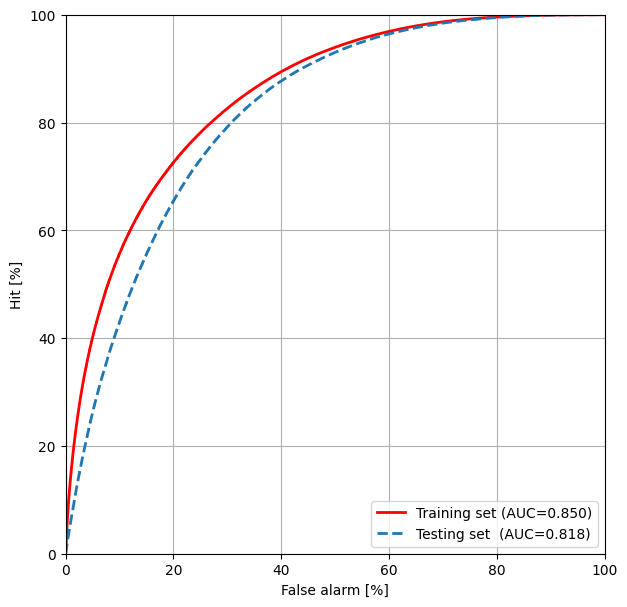

In [35]:
plot_roc(f"Training set (AUC={auc_train:.3f})", train_y.flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", test_y.flatten(), pred_y_test.flatten(), color=colors[0], linestyle='--')
plt.legend(loc='lower right');

## Precision-Recall

In [36]:
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = metrics.precision_recall_curve(labels, predictions)
    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')

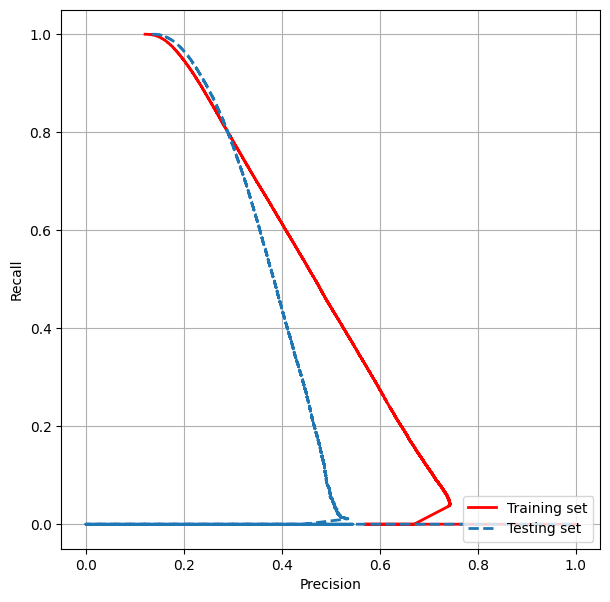

In [37]:
plot_prc(f"Training set", train_y.flatten(), pred_y_train.flatten(), color="red")
plot_prc(f"Testing set", test_y.flatten(), pred_y_test.flatten(), color=colors[0], linestyle='--')
plt.legend(loc='lower right');

## Reliability diagram

In [38]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

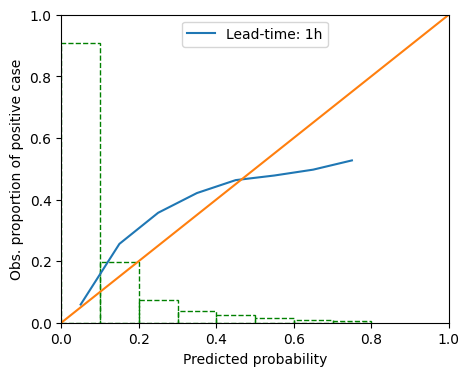

In [39]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(test_y.flatten(), pred_y_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"Lead-time: 1h")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

## Plotting

In [40]:
import cartopy.crs as ccrs                              # type: ignore
import cartopy.feature as cfeature                      # type: ignore
import warnings
warnings.filterwarnings("ignore")
from netCDF4 import Dataset                             # type: ignore

In [41]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [42]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

xlimit = 1803
ylimit = 556

lons = geodata["lons_mid"][:ylimit, :xlimit]
lats = geodata["lats_mid"][:ylimit, :xlimit]

In [43]:
original_y_min, original_x_min = nflics.X0(13, -18)
original_y_max, original_x_max = nflics.X0(16, -15)

# To fix dimensions

y_min = original_y_min - 2
y_max = original_y_max + 2
x_min = original_x_min 
x_max = original_x_max + 1

In [44]:
def downsample_grid(grid, factor):
    # Ensure that the grid dimensions are divisible by the factor
    assert grid.shape[0] % factor == 0
    assert grid.shape[1] % factor == 0

    # Reshape the grid to factor blocks and then take the mean
    grid_downsampled = grid.reshape(grid.shape[0] // factor, factor,
                                    grid.shape[1] // factor, factor).mean(axis=(1, 3))
    
    return grid_downsampled

def create_lat_lon_grid(latitudes, longitudes, factor):
    lat_min = latitudes.min()
    lat_max = latitudes.max()
    lon_min = longitudes.min()
    lon_max = longitudes.max()
    
    num_rows = latitudes.shape[0] // factor
    num_cols = longitudes.shape[1] // factor
    
    new_lats = np.linspace(lat_min, lat_max, num_rows)
    new_lons = np.linspace(lon_min, lon_max, num_cols)
    
    new_latitudes, new_longitudes = np.meshgrid(new_lats, new_lons, indexing='ij')
    
    return new_latitudes, new_longitudes

In [45]:
if resolution == 11:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 10)
else:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 5)

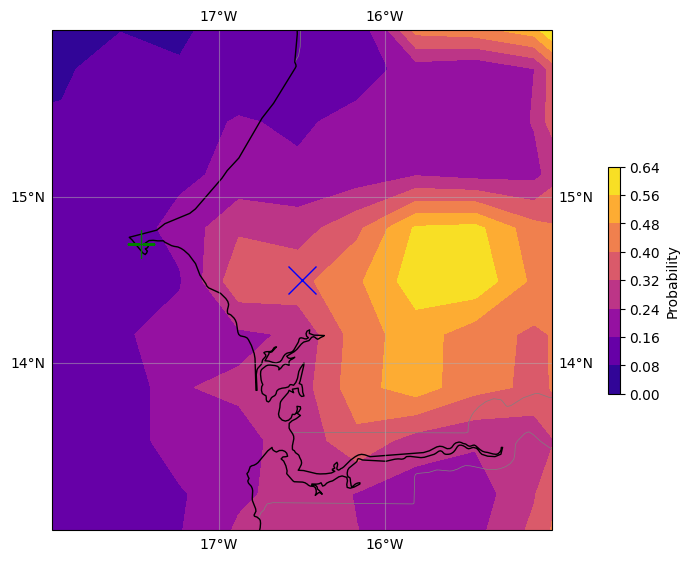

In [46]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

contour_core = ax.contourf(downsampled_lons, downsampled_lats, pred_y_test.reshape(n_test, resolution, resolution)[idx_max], transform=ccrs.PlateCarree(), cmap="plasma")
plt.colorbar(contour_core, label="Probability", fraction=0.02, pad=0.1)

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

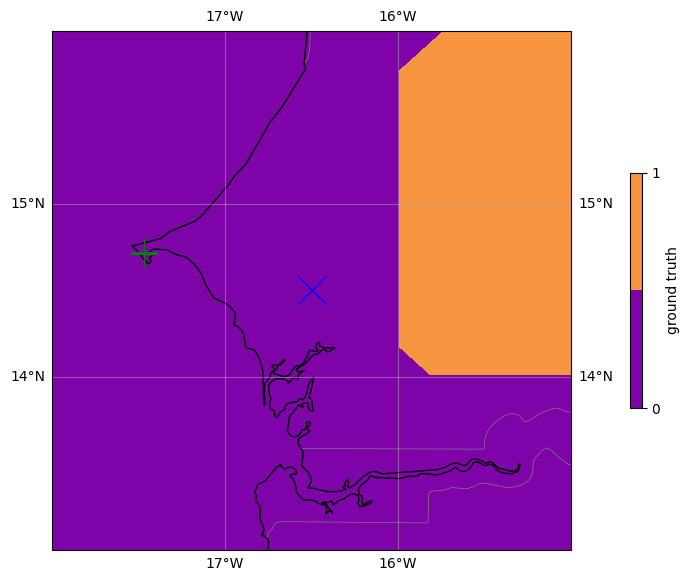

In [47]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

levels = [0, 0.5, 1]

contour_core = ax.contourf(downsampled_lons, downsampled_lats, test_y[idx_max], transform=ccrs.PlateCarree(), cmap="plasma", levels=levels)
cbar = plt.colorbar(contour_core, label="ground truth", fraction=0.02, pad=0.1)

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

## Take input value

In [48]:
#889

info_input = raw_test_data_X.iloc[idx_max, :]

In [49]:
info_input

year       2020.00
month         7.00
day           1.00
hour         18.00
minute       30.00
lat1         16.31
lon1        -13.34
lat2         15.86
lon2        -13.93
lat3         15.50
lon3        -13.07
lat4         15.14
lon4        -14.74
lat5         12.00
lon5        -13.97
wp1        2344.00
wp2        1437.00
wp3        6105.00
wp4        2158.00
wp5         145.00
size1     19775.00
size2     10300.00
size3     26800.00
size4      4700.00
size5      9475.00
ds1          65.19
ds2         102.88
ds3         118.19
ds4         124.33
ds5         129.00
Name: 890, dtype: float64

### Classification threshold

In [50]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

In [51]:
cl_threshold = cutoff_youdens_j(*metrics.roc_curve(test_y.flatten(), pred_y_test.flatten()))

In [52]:
cl_threshold

0.06627988

In [53]:
import numpy as np

def calculate_fss(forecast, observation, neighborhood_size=1):
    """
    Calculate the Fraction Skill Score (FSS) for a binary forecast and observation over a grid.
    Handles the case where both forecast and observation are all zeros.
    
    Args:
    - forecast (2D numpy array): Binary forecast data (1 for event, 0 for no event).
    - observation (2D numpy array): Binary observation data (1 for event, 0 for no event).
    - neighborhood_size (int): Size of the neighborhood window for fraction calculation.
    
    Returns:
    - FSS (float): The fraction skill score between forecast and observation.
    """
    forecast = np.array(forecast)
    observation = np.array(observation)
    
    if forecast.shape != observation.shape:
        raise ValueError("Forecast and observation must have the same shape.")
    
    # If both forecast and observation are all zeros, return perfect FSS (1)
    if np.all(forecast == 0) and np.all(observation == 0):
        return 1.0
    
    def compute_fraction(data, neighborhood_size):
        rows, cols = data.shape
        fraction = np.zeros_like(data, dtype=float)
        for i in range(rows):
            for j in range(cols):
                r_min = max(0, i - neighborhood_size)
                r_max = min(rows, i + neighborhood_size + 1)
                c_min = max(0, j - neighborhood_size)
                c_max = min(cols, j + neighborhood_size + 1)
                neighborhood = data[r_min:r_max, c_min:c_max]
                fraction[i, j] = np.mean(neighborhood)
        return fraction
    
    forecast_fraction = compute_fraction(forecast, neighborhood_size)
    observation_fraction = compute_fraction(observation, neighborhood_size)
    
    numerator = np.sum((forecast_fraction - observation_fraction) ** 2)
    denominator = np.sum(forecast_fraction ** 2 + observation_fraction ** 2)
    
    # To avoid division by zero, check if denominator is zero
    if denominator == 0:
        return 0.0  # If there's no signal at all, set FSS to 0
    
    fss = 1 - (numerator / denominator)
    return fss


In [54]:
test_y.shape

(17838, 11, 11)

In [55]:
calculate_fss(pred_y_test.reshape(n_test, resolution, resolution)[idx_max]>=0.5, test_y[idx_max], neighborhood_size=1)

0.5909231071118213

In [56]:
0.59

0.59

### For all instances

In [57]:
def calculate_fss_for_all_instances(forecasts, observations, neighborhood_size=1):
    """
    Calculate the FSS for each forecast-observation pair in the dataset and return the average FSS.
    
    Args:
    - forecasts (list of 2D numpy arrays): List of forecast grids for all instances.
    - observations (list of 2D numpy arrays): List of observation grids for all instances.
    - neighborhood_size (int): Size of the neighborhood window for fraction calculation.
    
    Returns:
    - average_fss (float): The average FSS over all instances.
    - fss_scores (list of floats): The FSS score for each instance.
    """
    fss_scores = []
    
    # Loop over each forecast-observation pair
    for forecast, observation in zip(forecasts, observations):
        fss = calculate_fss(forecast, observation, neighborhood_size)
        fss_scores.append(fss)
    
    # Compute the average FSS
    average_fss = np.mean(fss_scores)
    
    return average_fss, fss_scores

In [58]:
cl_threshold

0.06627988

In [59]:
average_fss, fss_scores = calculate_fss_for_all_instances(pred_y_test.reshape(n_test, resolution, resolution)>=0, test_y, neighborhood_size=3)

In [60]:
calculate_fss_for_all_instances(pred_y_test.reshape(n_test, resolution, resolution)>=0.5, test_y, neighborhood_size=2)[0]

0.5265168058849956

In [61]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
number_of_neighbours = [1, 2, 3]
result = []
for t in thresholds:
    for scale in number_of_neighbours:
        print(t, scale)
        result.append(t+scale)

0.1 1
0.1 2
0.1 3
0.3 1
0.3 2
0.3 3
0.5 1
0.5 2
0.5 3
0.7 1
0.7 2
0.7 3
0.9 1
0.9 2
0.9 3


In [62]:
np.array(result).reshape(len(thresholds), len(number_of_neighbours)).T

array([[1.1, 1.3, 1.5, 1.7, 1.9],
       [2.1, 2.3, 2.5, 2.7, 2.9],
       [3.1, 3.3, 3.5, 3.7, 3.9]])

In [63]:
average_fss

0.2112937953514411

In [64]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
number_of_neighbours = [1, 2, 3]

fss = []

for t in thresholds:
    for scale in number_of_neighbours:
        fss.append(calculate_fss_for_all_instances(pred_y_test.reshape(n_test, resolution, resolution)>=t, test_y, neighborhood_size=scale)[0])



In [65]:
fss_lt = np.array(fss).reshape(len(thresholds), len(number_of_neighbours)).T

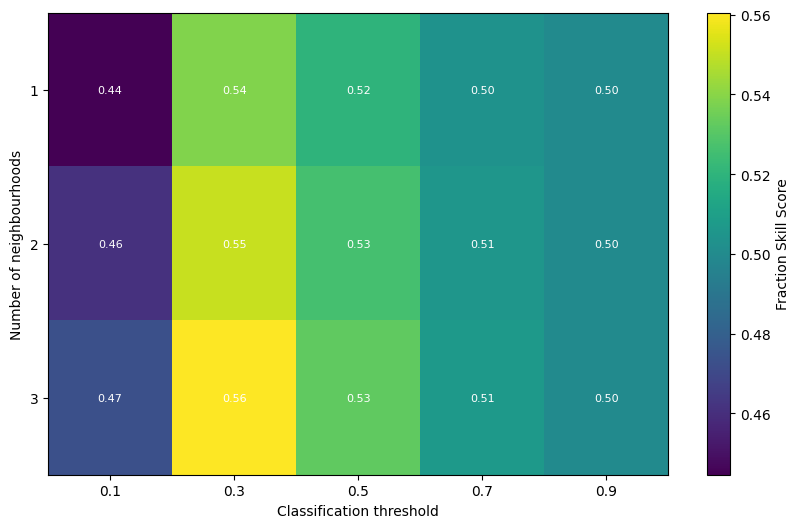

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(fss_lt, cmap='viridis', aspect='auto')

# Add a colorbar
cbar = plt.colorbar(cax)
cbar.set_label('Fraction Skill Score')

# Annotate each cell with its value, no need for positional adjustment in imshow
for i in range(fss_lt.shape[0]):
    for j in range(fss_lt.shape[1]):
        value = fss_lt[i, j]
        ax.text(j, i, f'{value:.2f}', 
                ha='center', va='center', 
                color='white', fontsize=8)

ytick_labels = [str(tick) for tick in number_of_neighbours] 
ax.set_yticks(np.array(number_of_neighbours)-1)
ax.set_yticklabels(ytick_labels)


xtick_labels = [str(tick) for tick in thresholds] 
ax.set_xticks(range(5))
ax.set_xticklabels(xtick_labels)


# Set labels and title
plt.xlabel('Classification threshold')
plt.ylabel('Number of neighbourhoods')
plt.show()